<a href="https://colab.research.google.com/github/Gabriellemga/Python_Data_Science_Alura/blob/main/Pandas_%20tratando_analisando_%20dados/Pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<font color = 'green' size = 5>Importando a base de dados</font>

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/aluguel.csv', sep = ';')
df

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
0,Quitinete,Copacabana,1,0,0,40,1700.0,500.0,60.0
1,Casa,Jardim Botânico,2,0,1,100,7000.0,NaN,NaN
2,Conjunto Comercial/Sala,Barra da Tijuca,0,4,0,150,5200.0,4020.0,1111.0
3,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0
4,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,NaN
...,...,...,...,...,...,...,...,...,...
32955,Quitinete,Centro,0,0,0,27,800.0,350.0,25.0
32956,Apartamento,Jacarepaguá,3,1,2,78,1800.0,800.0,40.0
32957,Apartamento,São Francisco Xavier,2,1,0,48,1400.0,509.0,37.0
32958,Apartamento,Leblon,2,0,0,70,3000.0,760.0,NaN


<font color = 'green' size = 5>Informações gerais sobre os dados</font>

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32960 entries, 0 to 32959
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Tipo        32960 non-null  object 
 1   Bairro      32960 non-null  object 
 2   Quartos     32960 non-null  int64  
 3   Vagas       32960 non-null  int64  
 4   Suites      32960 non-null  int64  
 5   Area        32960 non-null  int64  
 6   Valor       32943 non-null  float64
 7   Condominio  28867 non-null  float64
 8   IPTU        22723 non-null  float64
dtypes: float64(3), int64(4), object(2)
memory usage: 2.3+ MB


In [ ]:
tipos_de_dados = pd.DataFrame(df.dtypes, columns = ['Tipo de dados'])
tipos_de_dados.columns.name = 'Variáveis'
tipos_de_dados


Variáveis,Tipo de dados
Tipo,object
Bairro,object
Quartos,int64
Vagas,int64
Suites,int64
Area,int64
Valor,float64
Condominio,float64
IPTU,float64


<font color='green' size= 5>Tipos de imovéis</font>

In [ ]:
tipo_imovel = df['Tipo']

In [ ]:
tipo_imovel.drop_duplicates(inplace = True)

In [ ]:
tipo_imovel

,Tipo
0,Quitinete
1,Casa
2,Conjunto Comercial/Sala
3,Apartamento
7,Casa de Condomínio
16,Prédio Inteiro
17,Flat
29,Loja/Salão
80,Galpão/Depósito/Armazém
83,Casa Comercial


In [ ]:
tipo_imovel = pd.DataFrame(tipo_imovel)
tipo_imovel.reset_index(drop = True, inplace = True)
tipo_imovel.columns.name = 'Id'
tipo_imovel

Id,Tipo
0,Quitinete
1,Casa
2,Conjunto Comercial/Sala
3,Apartamento
4,Casa de Condomínio
5,Prédio Inteiro
6,Flat
7,Loja/Salão
8,Galpão/Depósito/Armazém
9,Casa Comercial


<font color = 'green' size = 5>Imovéis residenciais</font>

In [ ]:
list(df['Tipo'].drop_duplicates())

['Quitinete',
 'Casa',
 'Conjunto Comercial/Sala',
 'Apartamento',
 'Casa de Condomínio',
 'Prédio Inteiro',
 'Flat',
 'Loja/Salão',
 'Galpão/Depósito/Armazém',
 'Casa Comercial',
 'Casa de Vila',
 'Terreno Padrão',
 'Box/Garagem',
 'Loft',
 'Loja Shopping/ Ct Comercial',
 'Chácara',
 'Loteamento/Condomínio',
 'Sítio',
 'Pousada/Chalé',
 'Studio',
 'Hotel',
 'Indústria']

In [ ]:
residencial = ['Quitinete',
 'Casa',
 'Apartamento',
 'Casa de Condomínio',
 'Casa de Vila']

In [ ]:
residencial

['Quitinete', 'Casa', 'Apartamento', 'Casa de Condomínio', 'Casa de Vila']

In [ ]:
selecao = df['Tipo'].isin(residencial)
selecao

,Tipo
0,True
1,True
2,False
3,True
4,True
...,...
32955,True
32956,True
32957,True
32958,True


In [ ]:
df_residdencial = df[selecao]
df_residdencial.reset_index(drop = True, inplace = True)
df_residdencial

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
0,Quitinete,Copacabana,1,0,0,40,1700.0,500.0,60.0
1,Casa,Jardim Botânico,2,0,1,100,7000.0,NaN,NaN
2,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0
3,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,NaN
4,Apartamento,Vista Alegre,3,1,0,70,1200.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...
22575,Apartamento,Méier,2,0,0,70,900.0,490.0,48.0
22576,Quitinete,Centro,0,0,0,27,800.0,350.0,25.0
22577,Apartamento,Jacarepaguá,3,1,2,78,1800.0,800.0,40.0
22578,Apartamento,São Francisco Xavier,2,1,0,48,1400.0,509.0,37.0


In [ ]:
df_residdencial.to_csv('aluguel_residencial.csv', sep = ';', index = False)

<font color ='green' size = 5>Seleções de frequencia</font>

In [ ]:
df = pd.read_csv('/content/aluguel_residencial.csv', sep = ';')
df.head()

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
0,Quitinete,Copacabana,1,0,0,40,1700.0,500.0,60.0
1,Casa,Jardim Botânico,2,0,1,100,7000.0,NaN,NaN
2,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0
3,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,NaN
4,Apartamento,Vista Alegre,3,1,0,70,1200.0,NaN,NaN


In [ ]:
#Selecione somente os imóveis classificados com tipo 'Apartamento'.

selecao = df.query("Tipo == 'Apartamento'")
n1 = selecao['Tipo'].shape[0]
n1

19532

In [ ]:
#Selecione os imóveis classificados com tipos 'Casa', 'Casa de Condomínio' e 'Casa de Vila'.
selecao = df[df['Tipo'].isin(['Casa', 'Casa de Condomínio', 'Casa de Vila'])]
n2 = selecao['Tipo'].shape[0]
n2

2212

In [ ]:
#Selecione os imóveis com área entre 60 e 100 metros quadrados, incluindo os limites.
selecao = (df['Area'] >= 60) & (df['Area'] <= 100)
n3 = df[selecao].shape[0]
n3

8719

In [ ]:
#Selecione os imóveis que tenham pelo menos 4 quartos e aluguel menor que R$ 2.000,00.
selecao = df[(df['Quartos'] >= 4) & (df['Valor'] < 2000)]
n4 = selecao['Quartos'].shape[0]
n4

41

In [ ]:
print("Nº de imóveis classificados com tipo 'Apartamento' -> {}".format(n1))
print("Nº de imóveis classificados com tipos 'Casa', 'Casa de Condomínio' e 'Casa de Vila'-> {}".format(n2))
print("Nº de imóveis com área entre 60 e 100 metros quadrados, incluindo os limites -> {}".format(n3))
print("Nº de imóveis que tenham pelo menos 4 quartos e aluguel menor que R$ 2.000,00 -> {}".format(n4))

Nº de imóveis classificados com tipo 'Apartamento' -> 19532
Nº de imóveis classificados com tipos 'Casa', 'Casa de Condomínio' e 'Casa de Vila'-> 2212
Nº de imóveis com área entre 60 e 100 metros quadrados, incluindo os limites -> 8719
Nº de imóveis que tenham pelo menos 4 quartos e aluguel menor que R$ 2.000,00 -> 41


In [ ]:
selecao

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
484,Apartamento,Recreio dos Bandeirantes,4,2,2,160,1900.0,830.0,NaN
1003,Apartamento,Taquara,4,1,1,110,1900.0,NaN,NaN
1961,Casa,Campo Grande,4,1,4,100,1600.0,NaN,NaN
2102,Casa,Engenho de Dentro,4,3,0,120,1500.0,NaN,NaN
2200,Apartamento,Recreio dos Bandeirantes,4,2,2,125,1700.0,NaN,90.0
2338,Casa de Vila,Méier,4,0,1,85,1600.0,NaN,NaN
3943,Casa,Campo Grande,4,1,0,140,1700.0,NaN,NaN
3944,Apartamento,Campo Grande,4,2,1,115,1900.0,500.0,NaN
4349,Apartamento,Recreio dos Bandeirantes,4,2,1,105,1900.0,1492.0,205.0
5081,Apartamento,Cidade Nova,4,0,0,110,1300.0,NaN,NaN


<font color = 'green' size = 5>Tratamento de dados faltantes</font>

In [ ]:
df.isnull()

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,True,True
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,True
4,False,False,False,False,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...
22575,False,False,False,False,False,False,False,False,False
22576,False,False,False,False,False,False,False,False,False
22577,False,False,False,False,False,False,False,False,False
22578,False,False,False,False,False,False,False,False,False


In [ ]:
df[df['Valor'].isnull()]

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
58,Apartamento,Barra da Tijuca,2,1,1,70,NaN,970.0,68.0
1492,Apartamento,Leme,2,0,0,75,NaN,878.0,NaN
1683,Casa,Campo Grande,3,4,3,363,NaN,NaN,NaN
2012,Apartamento,Botafogo,2,0,0,95,NaN,1010.0,170.0
2034,Apartamento,Copacabana,2,0,0,72,NaN,850.0,NaN
4941,Casa,Campo Grande,3,2,1,100,NaN,NaN,NaN
8568,Apartamento,Leme,2,0,1,75,NaN,878.0,NaN
8947,Apartamento,Glória,3,0,1,135,NaN,910.0,228.0
9149,Apartamento,Gávea,3,1,1,105,NaN,880.0,221.0


In [ ]:
df.dropna(subset=['Valor'], inplace = True)

In [ ]:
df[df['Condominio'].isnull()].shape[0]

1813

In [ ]:
selecao = (df['Tipo'] == 'Apartamento') & (df['Condominio'].isnull())

In [ ]:
df = df[~selecao]

In [ ]:
df[df['Condominio'].isnull()].shape[0]

1068

In [ ]:
df.fillna(0, inplace = True)

In [ ]:
df

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
0,Quitinete,Copacabana,1,0,0,40,1700.0,500.0,60.0
1,Casa,Jardim Botânico,2,0,1,100,7000.0,0.0,0.0
2,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0
3,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,0.0
5,Apartamento,Cachambi,2,0,0,50,1300.0,301.0,17.0
...,...,...,...,...,...,...,...,...,...
22575,Apartamento,Méier,2,0,0,70,900.0,490.0,48.0
22576,Quitinete,Centro,0,0,0,27,800.0,350.0,25.0
22577,Apartamento,Jacarepaguá,3,1,2,78,1800.0,800.0,40.0
22578,Apartamento,São Francisco Xavier,2,1,0,48,1400.0,509.0,37.0


In [ ]:
df.to_csv('aluguel_residencial.csv', sep = ';', index = False)

<font color = 'green' size = 5>Criando novas variáveis</font>

In [ ]:
df.head()

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
0,Quitinete,Copacabana,1,0,0,40,1700.0,500.0,60.0
1,Casa,Jardim Botânico,2,0,1,100,7000.0,0.0,0.0
2,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0
3,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,0.0
5,Apartamento,Cachambi,2,0,0,50,1300.0,301.0,17.0


In [ ]:
df['Valor_Bruto'] = df['Valor'] + df['Condominio'] + df['IPTU']
df.head()

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU,Valor_Bruto
0,Quitinete,Copacabana,1,0,0,40,1700.0,500.0,60.0,2260.0
1,Casa,Jardim Botânico,2,0,1,100,7000.0,0.0,0.0,7000.0
2,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0,1210.0
3,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,0.0,1030.0
5,Apartamento,Cachambi,2,0,0,50,1300.0,301.0,17.0,1618.0


In [ ]:
df['Valor_m2'] = (df['Valor'] / df['Area']).round(2)
df.head()

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU,Valor_Bruto,Valor_m2
0,Quitinete,Copacabana,1,0,0,40,1700.0,500.0,60.0,2260.0,42.50
1,Casa,Jardim Botânico,2,0,1,100,7000.0,0.0,0.0,7000.0,70.00
2,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0,1210.0,53.33
3,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,0.0,1030.0,16.67
5,Apartamento,Cachambi,2,0,0,50,1300.0,301.0,17.0,1618.0,26.00


In [ ]:
df['Valor Bruto m2'] = (df['Valor'] / df['Area']).round(2)
df

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU,Valor_Bruto,Valor_m2,Valor Bruto m2
0,Quitinete,Copacabana,1,0,0,40,1700.0,500.0,60.0,2260.0,42.50,42.50
1,Casa,Jardim Botânico,2,0,1,100,7000.0,0.0,0.0,7000.0,70.00,70.00
2,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0,1210.0,53.33,53.33
3,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,0.0,1030.0,16.67,16.67
5,Apartamento,Cachambi,2,0,0,50,1300.0,301.0,17.0,1618.0,26.00,26.00
...,...,...,...,...,...,...,...,...,...,...,...,...
22575,Apartamento,Méier,2,0,0,70,900.0,490.0,48.0,1438.0,12.86,12.86
22576,Quitinete,Centro,0,0,0,27,800.0,350.0,25.0,1175.0,29.63,29.63
22577,Apartamento,Jacarepaguá,3,1,2,78,1800.0,800.0,40.0,2640.0,23.08,23.08
22578,Apartamento,São Francisco Xavier,2,1,0,48,1400.0,509.0,37.0,1946.0,29.17,29.17


In [ ]:
casa = ['Casa', 'Casa de Condomínio', 'Casa de Vila']

In [ ]:
df['Tipo Agregado'] = df['Tipo'].apply(lambda x: 'Casa' if x in casa else 'Apartamento')
df

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU,Valor_Bruto,Valor_m2,Valor Bruto m2,Tipo Agregado
0,Quitinete,Copacabana,1,0,0,40,1700.0,500.0,60.0,2260.0,42.50,42.50,Apartamento
1,Casa,Jardim Botânico,2,0,1,100,7000.0,0.0,0.0,7000.0,70.00,70.00,Casa
2,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0,1210.0,53.33,53.33,Apartamento
3,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,0.0,1030.0,16.67,16.67,Apartamento
5,Apartamento,Cachambi,2,0,0,50,1300.0,301.0,17.0,1618.0,26.00,26.00,Apartamento
...,...,...,...,...,...,...,...,...,...,...,...,...,...
22575,Apartamento,Méier,2,0,0,70,900.0,490.0,48.0,1438.0,12.86,12.86,Apartamento
22576,Quitinete,Centro,0,0,0,27,800.0,350.0,25.0,1175.0,29.63,29.63,Apartamento
22577,Apartamento,Jacarepaguá,3,1,2,78,1800.0,800.0,40.0,2640.0,23.08,23.08,Apartamento
22578,Apartamento,São Francisco Xavier,2,1,0,48,1400.0,509.0,37.0,1946.0,29.17,29.17,Apartamento


<font color = 'green' size = 5>Excluindo variáveis</font>

In [ ]:
df.drop(['Valor_Bruto', 'Valor Bruto m2'], axis = 1, inplace = True)

In [ ]:
df.head()

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU,Valor_m2,Tipo Agregado
0,Quitinete,Copacabana,1,0,0,40,1700.0,500.0,60.0,42.50,Apartamento
1,Casa,Jardim Botânico,2,0,1,100,7000.0,0.0,0.0,70.00,Casa
2,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0,53.33,Apartamento
3,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,0.0,16.67,Apartamento
5,Apartamento,Cachambi,2,0,0,50,1300.0,301.0,17.0,26.00,Apartamento


In [ ]:
df.to_csv('aluguel_residencial.csv', sep = ';', index = False)

<font color = 'green' size = 5>Criando agrupamentos</font>

In [ ]:
df.head()

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU,Valor_m2,Tipo Agregado
0,Quitinete,Copacabana,1,0,0,40,1700.0,500.0,60.0,42.50,Apartamento
1,Casa,Jardim Botânico,2,0,1,100,7000.0,0.0,0.0,70.00,Casa
2,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0,53.33,Apartamento
3,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,0.0,16.67,Apartamento
5,Apartamento,Cachambi,2,0,0,50,1300.0,301.0,17.0,26.00,Apartamento


In [ ]:
df['Valor'].mean()

np.float64(5046.172821405663)

In [ ]:
bairros = ['Barra da Tijuca', 'Copacabana', 'Ipanema', 'Leblon', 'Botafogo', 'Flamengo', 'Tijuca']
selecao = df['Bairro'].isin(bairros)
dados = df[selecao]

In [ ]:
grupo_bairro = dados.groupby('Bairro')[['Valor','Condominio']].mean().round(2)
grupo_bairro

,Valor,Condominio
Bairro,,
Barra da Tijuca,7069.55,3591.01
Botafogo,8791.83,976.28
Copacabana,4126.68,1148.68
Flamengo,4113.53,1102.15
Ipanema,9352.00,2244.44
Leblon,8746.34,2107.18
Tijuca,2043.52,711.69


<font color = 'green' size = 5>Estatisticas descritivas</font>

In [ ]:
dados.groupby('Bairro')['Valor'].describe().round(2)


,count,mean,std,min,25%,50%,75%,max
Bairro,,,,,,,,
Barra da Tijuca,3863.0,7069.55,11874.15,800.0,2500.0,4500.0,8500.0,600000.0
Botafogo,873.0,8791.83,152202.41,700.0,2200.0,3000.0,4350.0,4500000.0
Copacabana,2644.0,4126.68,3611.41,100.0,2000.0,3000.0,4800.0,35000.0
Flamengo,714.0,4113.53,3839.13,800.0,1900.0,2900.0,4975.0,35000.0
Ipanema,1764.0,9352.00,8219.72,1200.0,4500.0,7000.0,11000.0,90000.0
Leblon,1258.0,8746.34,7004.04,100.0,4500.0,7000.0,10500.0,100000.0
Tijuca,1100.0,2043.52,1664.34,750.0,1500.0,1800.0,2300.0,45000.0


In [ ]:
dados.groupby('Bairro')['Valor'].agg(['mean', 'min', 'max']).rename(columns = {'mean': 'Média','min': 'Mínimo', 'max': 'Máximo'})

,Média,Mínimo,Máximo
Bairro,,,
Barra da Tijuca,7069.552938,800.0,600000.0
Botafogo,8791.828179,700.0,4500000.0
Copacabana,4126.677005,100.0,35000.0
Flamengo,4113.526611,800.0,35000.0
Ipanema,9352.001134,1200.0,90000.0
Leblon,8746.344992,100.0,100000.0
Tijuca,2043.520000,750.0,45000.0


In [ ]:
import matplotlib.pyplot as plt


In [ ]:
plt.rc('figure', figsize = (20,10))

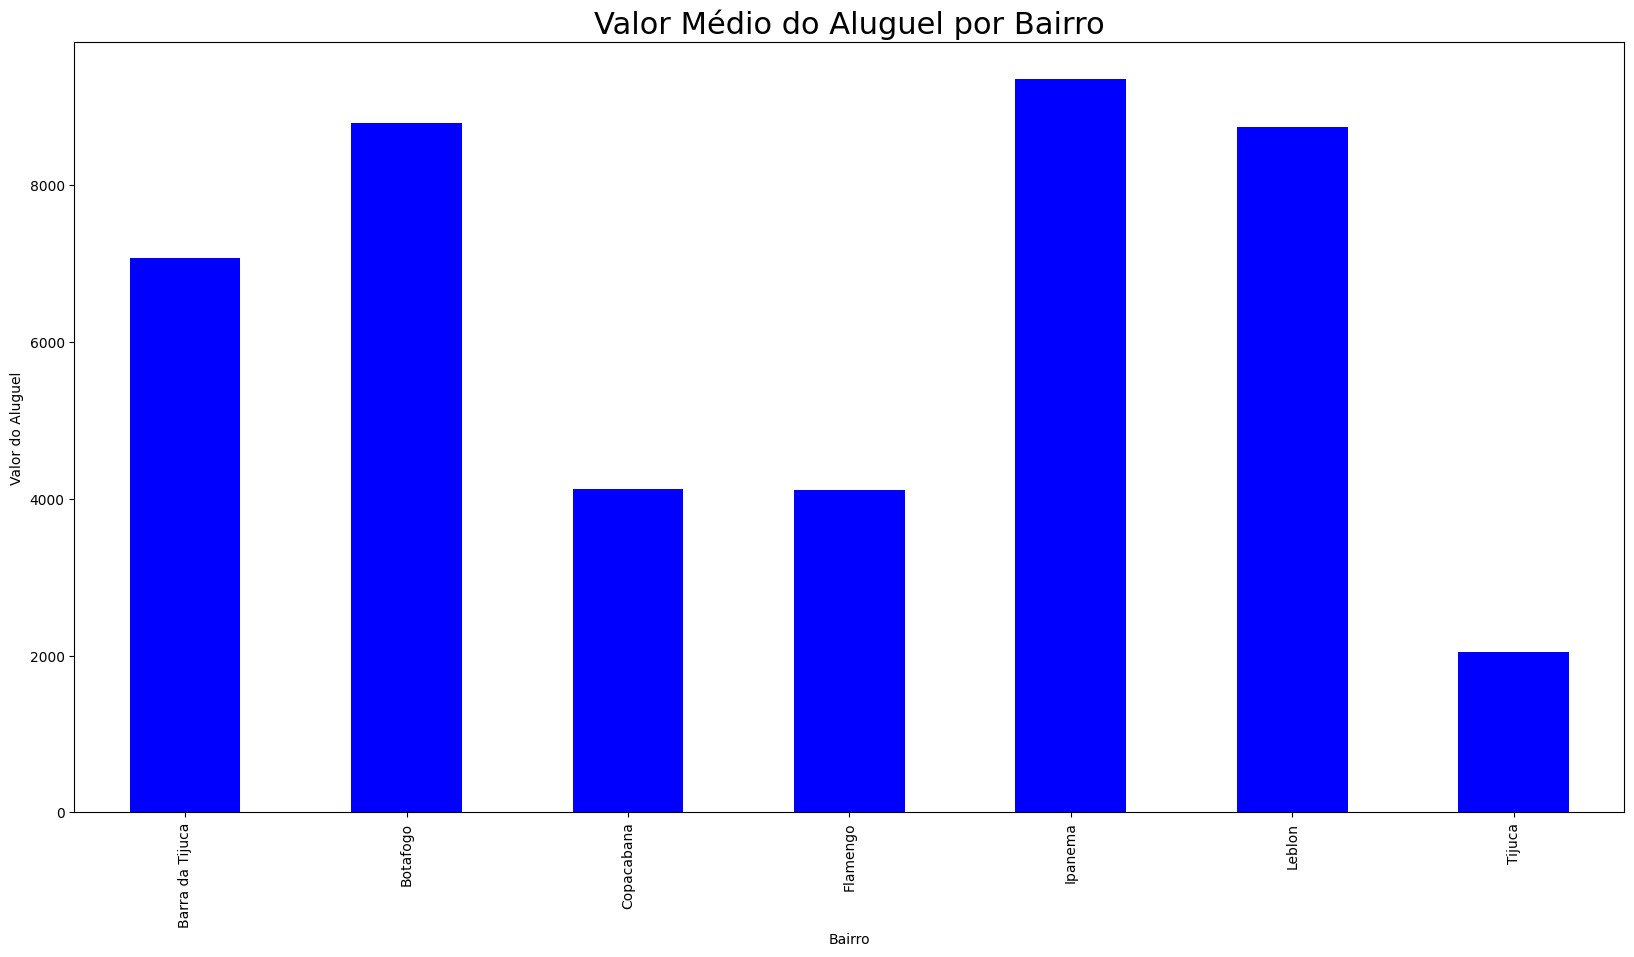

In [ ]:
fig = dados.groupby('Bairro')['Valor'].mean().plot.bar(color = 'blue')
fig.set_ylabel('Valor do Aluguel')
fig.set_title('Valor Médio do Aluguel por Bairro', {'fontsize': 22})
plt.show()

<font color = 'green' size = 5>Identificando e removendo outliers</font>

In [ ]:
df = pd.read_csv('/content/aluguel_residencial.csv',sep=';')
df.head()

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU,Valor_m2,Tipo Agregado
0,Quitinete,Copacabana,1,0,0,40,1700.0,500.0,60.0,42.50,Apartamento
1,Casa,Jardim Botânico,2,0,1,100,7000.0,0.0,0.0,70.00,Casa
2,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0,53.33,Apartamento
3,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,0.0,16.67,Apartamento
4,Apartamento,Cachambi,2,0,0,50,1300.0,301.0,17.0,26.00,Apartamento


<Axes: >

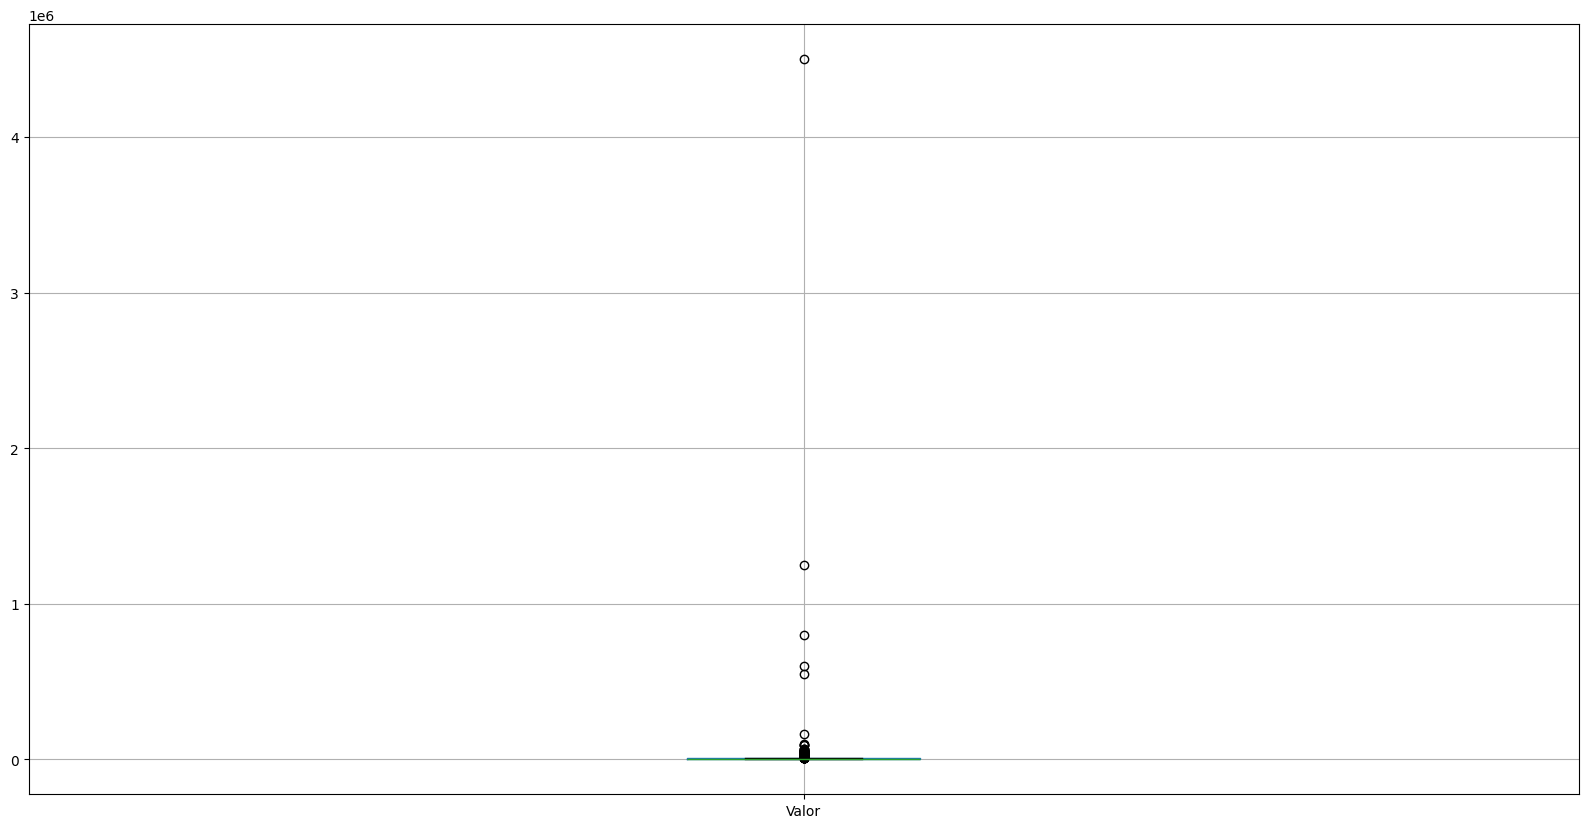

In [ ]:
df.boxplot(['Valor'])

In [ ]:
df[df['Valor'] >= 500000]

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU,Valor_m2,Tipo Agregado
7629,Apartamento,Barra da Tijuca,1,1,0,65,600000.0,980.0,120.0,9230.77,Apartamento
10636,Casa de Condomínio,Freguesia (Jacarepaguá),4,2,3,163,800000.0,900.0,0.0,4907.98,Casa
12661,Apartamento,Freguesia (Jacarepaguá),2,2,1,150,550000.0,850.0,150.0,3666.67,Apartamento
13846,Apartamento,Recreio dos Bandeirantes,3,2,1,167,1250000.0,1186.0,320.0,7485.03,Apartamento
15520,Apartamento,Botafogo,4,1,1,300,4500000.0,1100.0,0.0,15000.00,Apartamento


In [ ]:
valor = df['Valor']

In [ ]:
Q1 = valor.quantile(.25)
Q3 = valor.quantile(.75)
IIQ = Q3 - Q1
limite_inferior = Q1 - 1.5 * IIQ
limite_superior = Q3 + 1.5 * IIQ

In [ ]:
selecao = (valor >= limite_inferior) & (valor <= limite_superior)
dados_sem_outliers = df[selecao]

<Axes: >

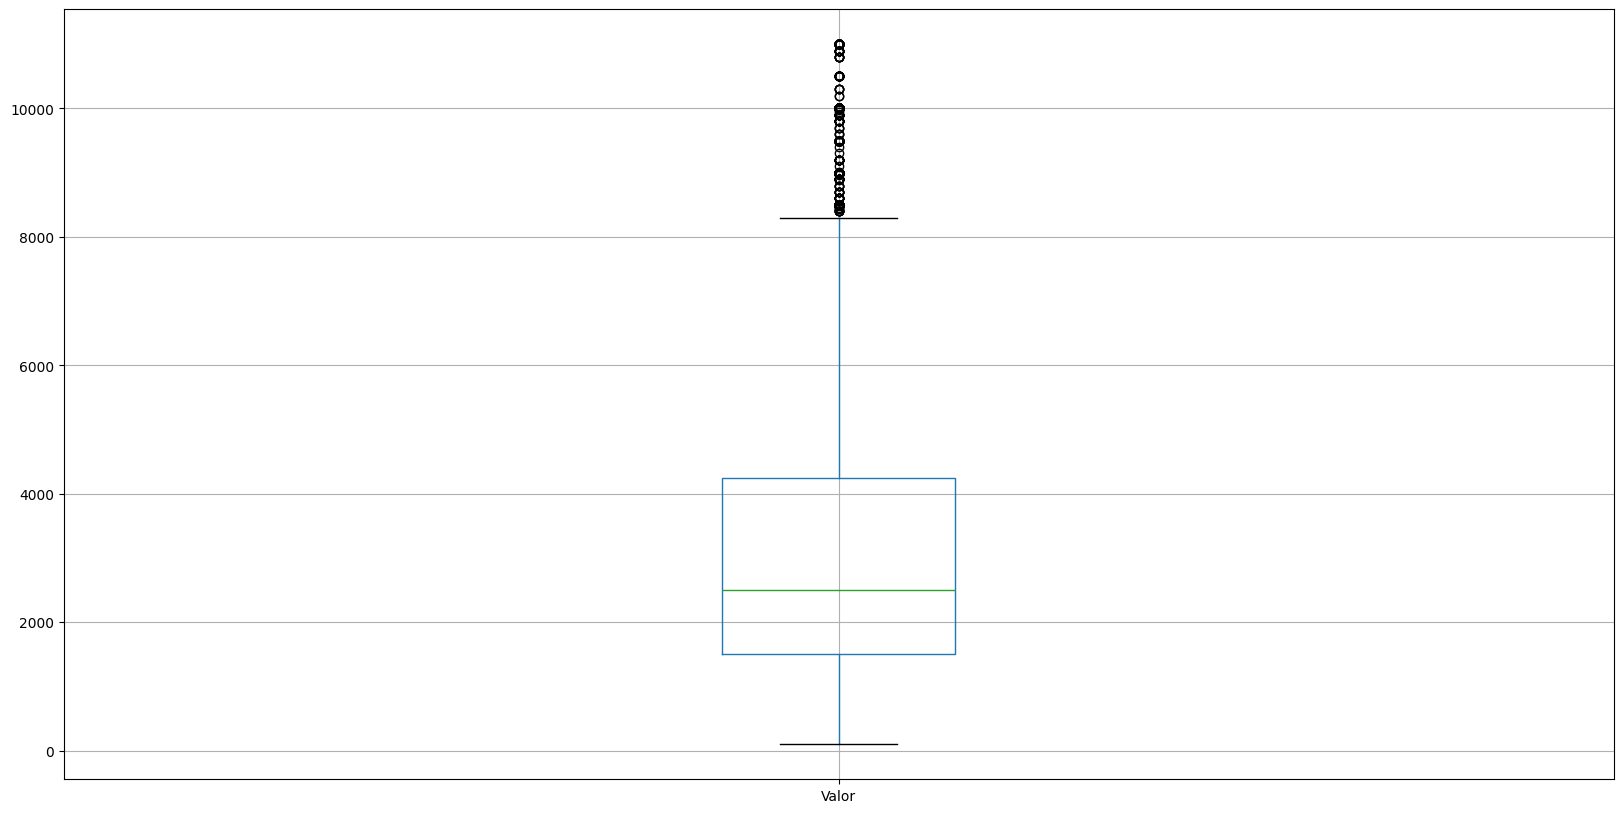

In [ ]:
dados_sem_outliers.boxplot(['Valor'])

array([[<Axes: title={'center': 'Valor'}>]], dtype=object)

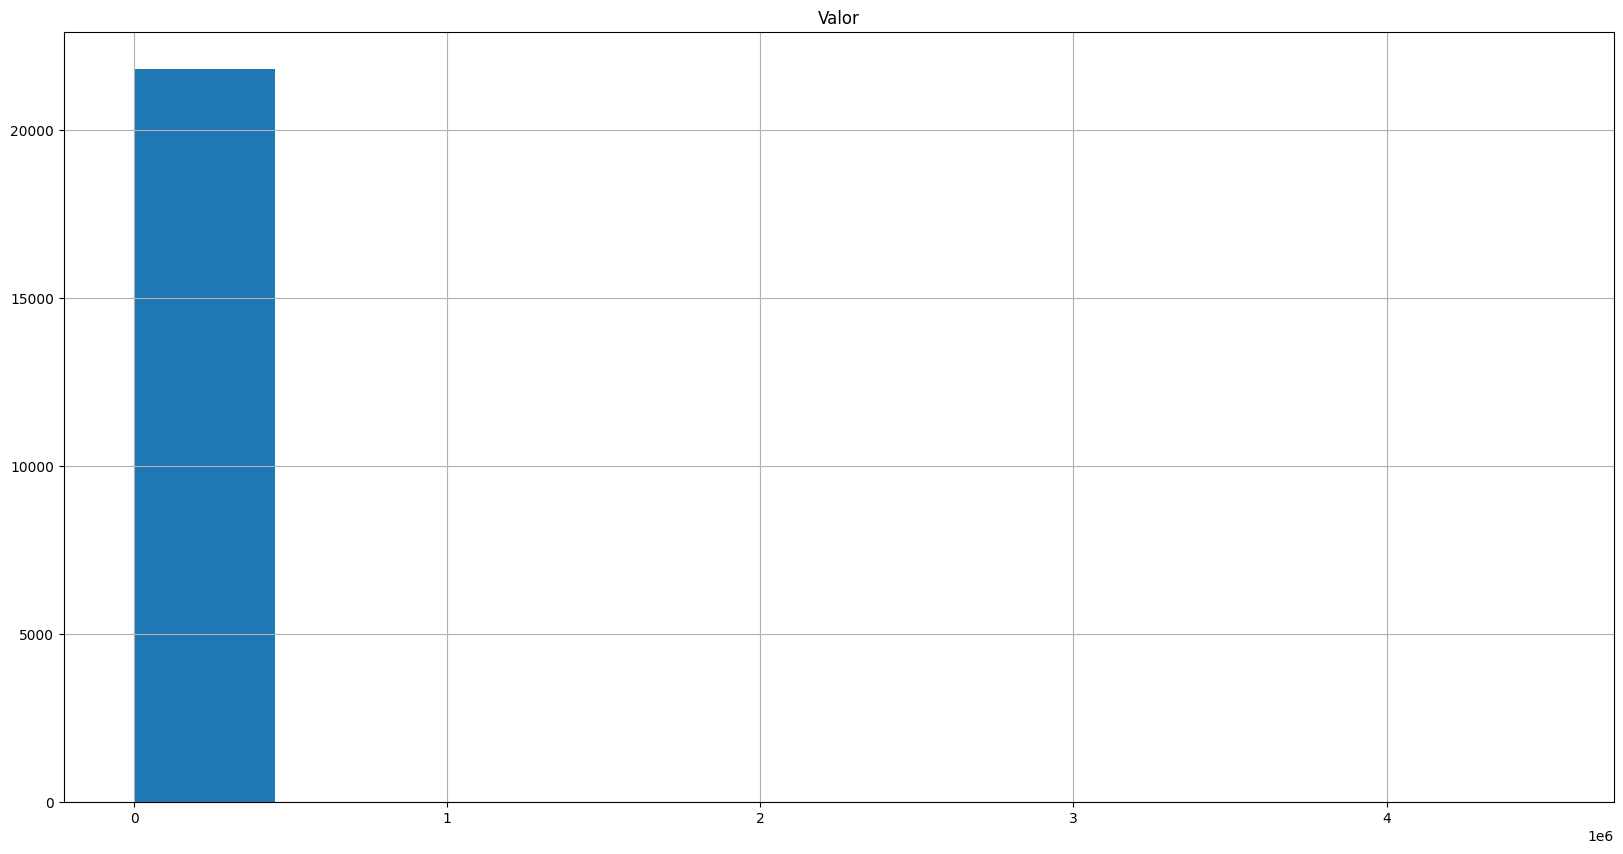

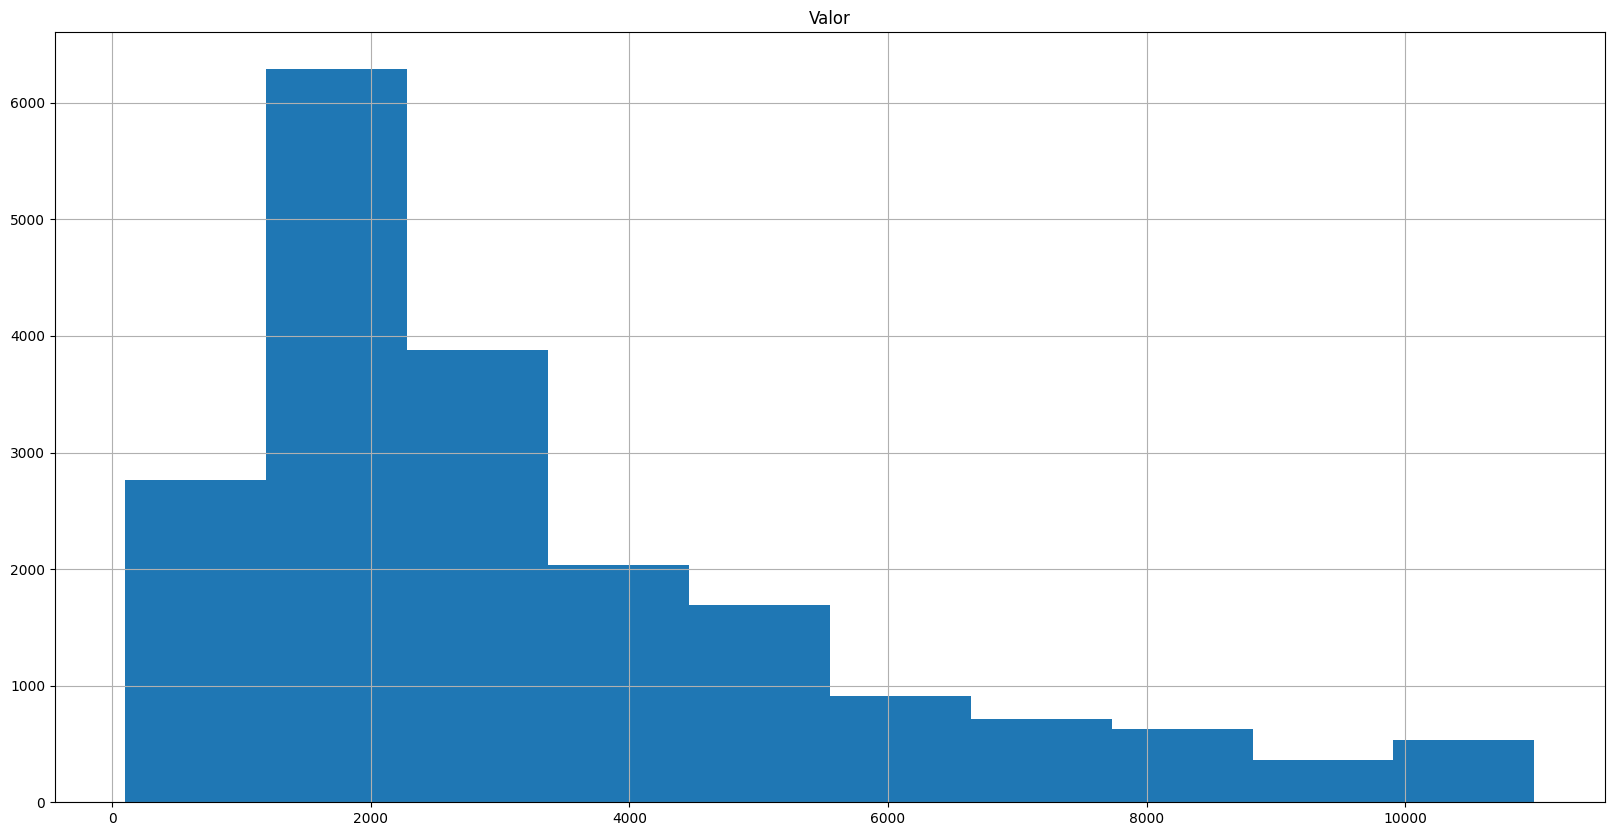

In [ ]:
df.hist(['Valor'])
dados_sem_outliers.hist(['Valor'])

<Axes: title={'center': 'Valor'}, xlabel='[Tipo]'>

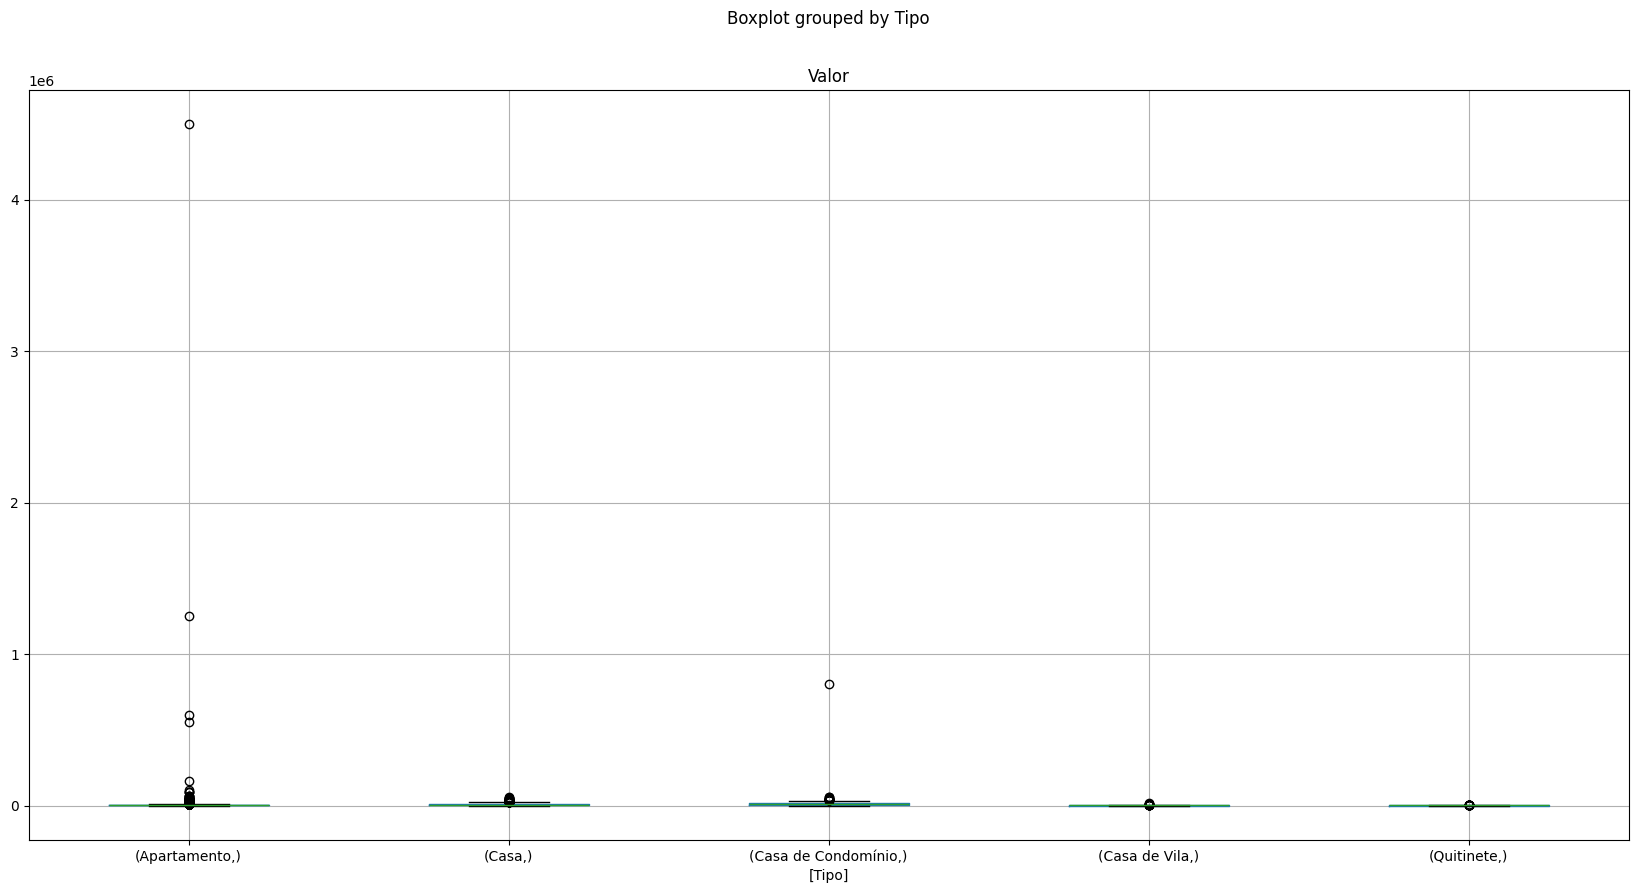

In [ ]:
df.boxplot(['Valor'], by = ['Tipo'])

In [ ]:
grupo_tipo = df.groupby('Tipo')['Valor']

In [ ]:
type(grupo_tipo)

pandas.core.groupby.generic.SeriesGroupBy

In [ ]:
grupo_tipo.groups

{'Apartamento': [2, 3, 4, 7, 8, 9, 11, 13, 14, 15, 17, 18, 19, 20, 21, 23, 24, 25, 26, 27, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 55, 56, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 72, 73, 74, 75, 76, 77, 79, 80, 82, 83, 84, 85, 87, 88, 89, 90, 91, 92, 93, 94, 95, 97, 98, 99, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, ...], 'Casa': [1, 22, 54, 57, 96, 100, 144, 160, 180, 238, 250, 253, 264, 286, 310, 316, 334, 339, 357, 378, 385, 399, 424, 434, 474, 475, 481, 511, 542, 543, 567, 571, 572, 618, 621, 630, 635, 636, 660, 676, 700, 721, 724, 760, 771, 780, 856, 873, 937, 982, 1029, 1036, 1118, 1123, 1125, 1157, 1178, 1249, 1256, 1316, 1335, 1350, 1371, 1412, 1426, 1430, 1440, 1445, 1472, 1475, 1488, 1586, 1604, 1656, 1662, 1666, 1671, 1684, 1709, 1717, 1762, 1810, 1835, 1875, 1905, 1933, 1942, 1960, 2019, 2039, 2056, 2075, 2101, 2107, 2108, 2133, 2170, 2201, 2204, 2211, ...], 'Casa 

In [ ]:
Q1 = grupo_tipo.quantile(.25)
Q3 = grupo_tipo.quantile(.75)
IIQ = Q3 - Q1
limite_inferior = Q1 - 1.5 * IIQ
limite_superior = Q3 + 1.5 * IIQ

In [ ]:
Q1

,Valor
Tipo,
Apartamento,1700.0
Casa,1100.0
Casa de Condomínio,4000.0
Casa de Vila,750.0
Quitinete,900.0


In [ ]:
Q3

,Valor
Tipo,
Apartamento,5000.0
Casa,9800.0
Casa de Condomínio,15250.0
Casa de Vila,1800.0
Quitinete,1500.0


In [ ]:
limite_inferior

,Valor
Tipo,
Apartamento,-3250.0
Casa,-11950.0
Casa de Condomínio,-12875.0
Casa de Vila,-825.0
Quitinete,0.0


In [ ]:
limite_superior

,Valor
Tipo,
Apartamento,9950.0
Casa,22850.0
Casa de Condomínio,32125.0
Casa de Vila,3375.0
Quitinete,2400.0


In [ ]:
df_new = pd.DataFrame()
for tipo in grupo_tipo.groups.keys():
  eh_tipo = df['Tipo'] == tipo
  eh_dentro_limite = (df['Valor'] >= limite_inferior[tipo]) & (df['Valor'] <= limite_superior[tipo])
  selecao = eh_tipo & eh_dentro_limite
  df_selecao = df[selecao]
  df_new = pd.concat([df_new, df_selecao])


<Axes: title={'center': 'Valor'}, xlabel='[Tipo]'>

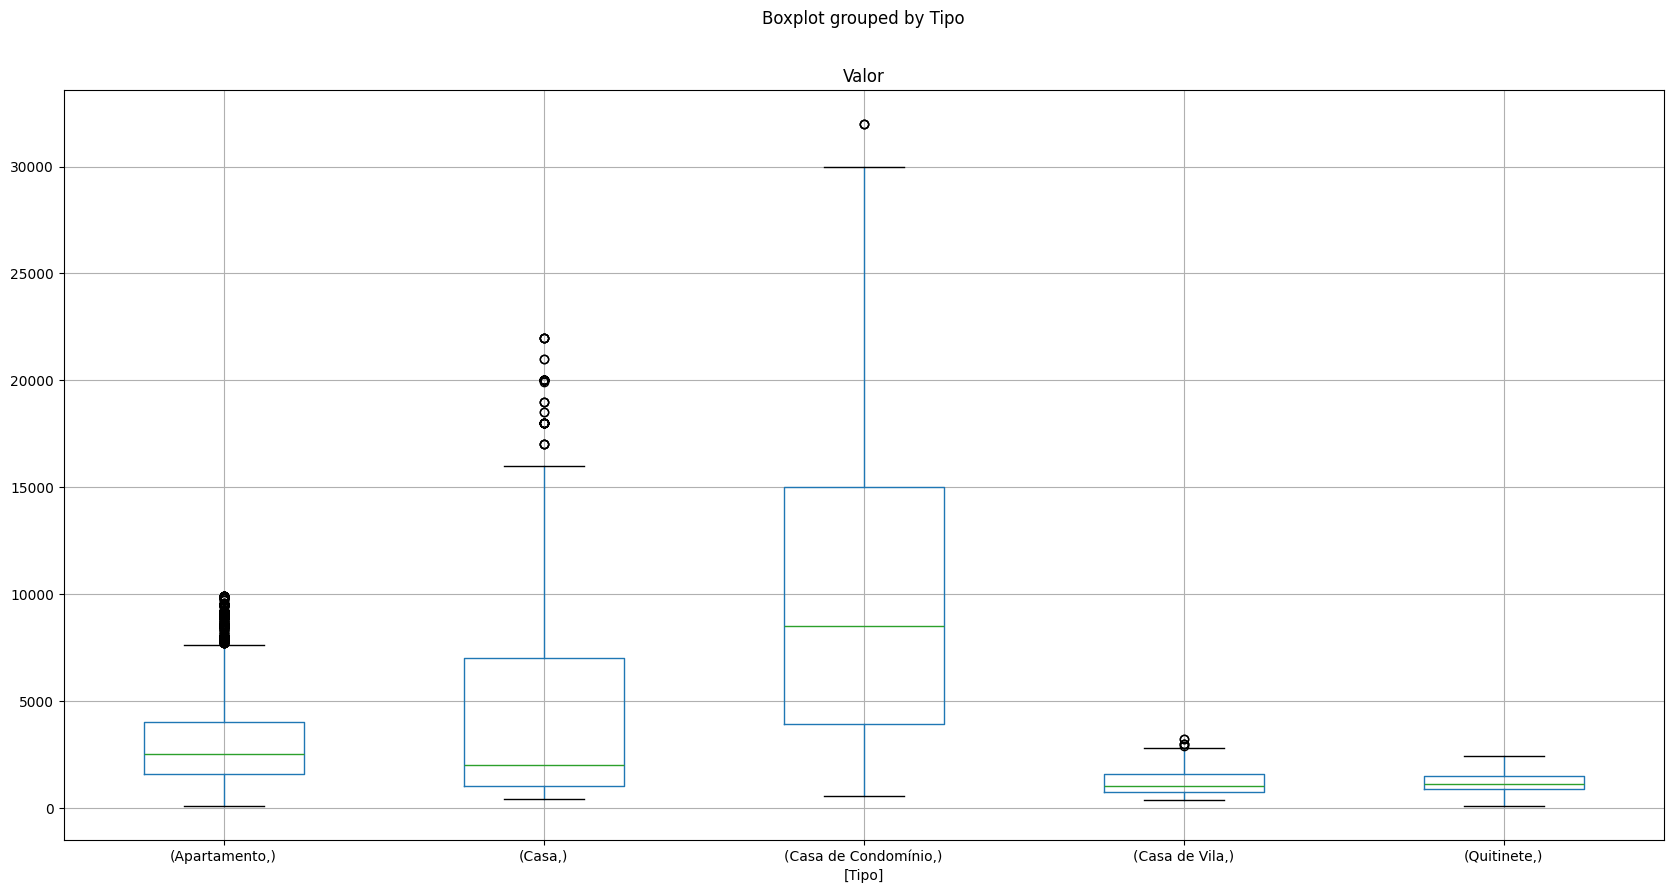

In [ ]:
df_new.boxplot(['Valor'], by = ['Tipo'])

In [ ]:
df_new.to_csv('aluguel_residencial_sem_outliers.csv', sep = ';', index = False)

Text(0.5, 1.0, 'Valor Médio por Tipo')

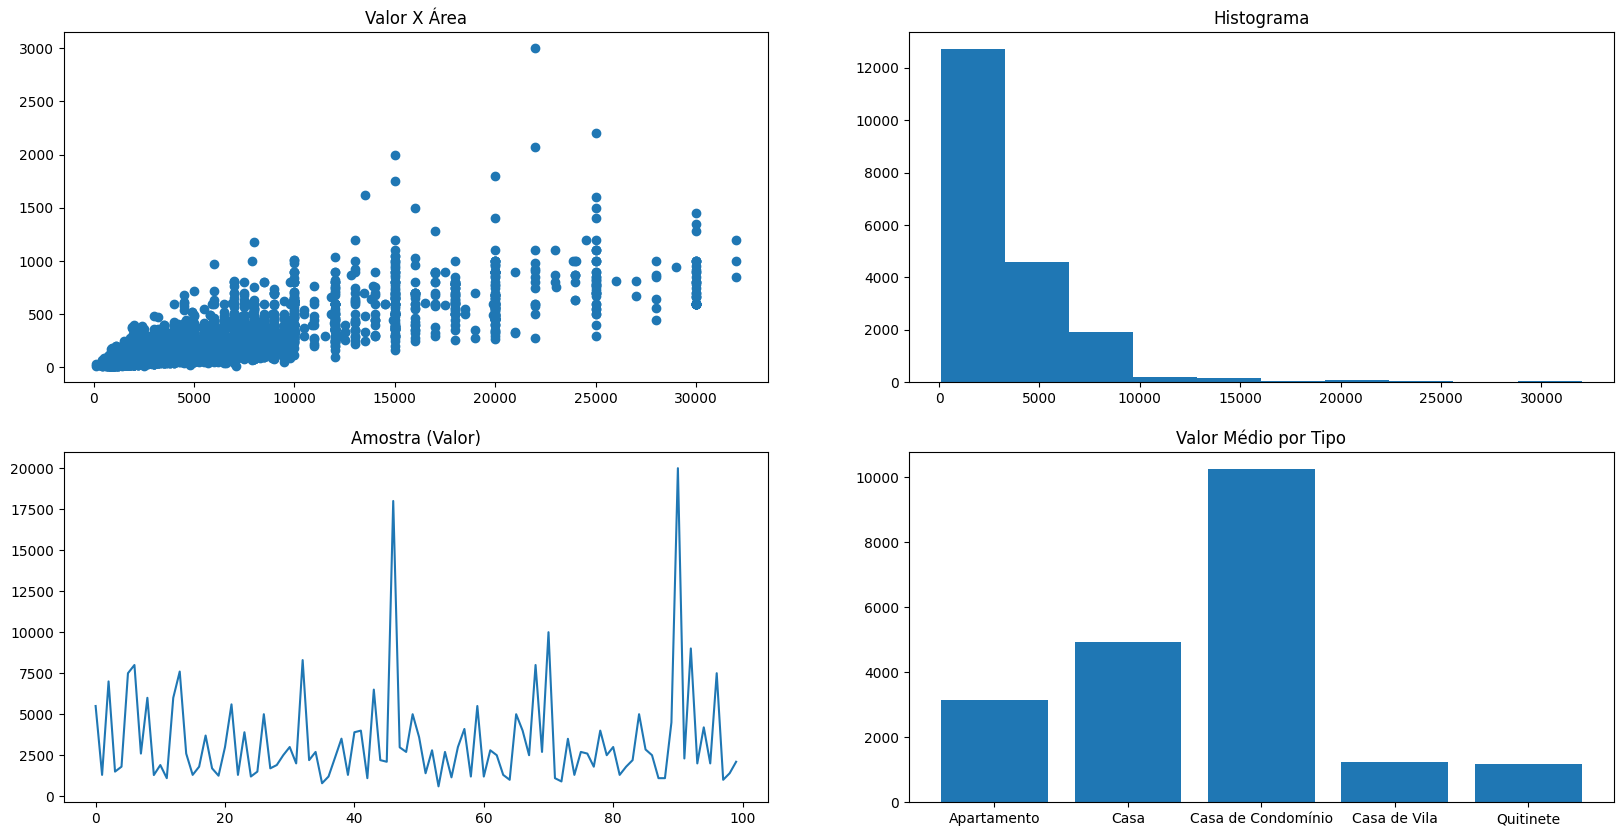

In [ ]:
area = plt.figure()
g1 = area.add_subplot(2, 2, 1)
g2 = area.add_subplot(2, 2, 2)
g3 = area.add_subplot(2, 2, 3)
g4 = area.add_subplot(2, 2, 4)

g1.scatter(df_new.Valor, df_new.Area)
g1.set_title('Valor X Área')


g2.hist(df_new.Valor)
g2.set_title('Histograma')


_new_g3 = df_new.Valor.sample(100)
_new_g3.index = range(_new_g3.shape[0])
g3.plot(_new_g3)
g3.set_title('Amostra (Valor)')

grupo = df_new.groupby('Tipo')['Valor']
label = grupo.mean().index
valores = grupo.mean().values
g4.bar(label, valores)
g4.set_title('Valor Médio por Tipo')

In [ ]:
area.savefig('grafico.png', dpi = 300, bbox_inches = 'tight')